# rfscorer Basic Usage

This notebook demonstrates the basic workflow of `rfscorer`:

1. Load an interaction log and split into train / test sets
2. Fit the scorer to estimate empirical revisit probabilities
3. Optimize probabilities under RF monotonicity constraints
4. Generate recommendation scores with `transform()`
5. Evaluate recommendation quality with `evaluate()`

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer

## 1. Load Data

The interaction log has three columns: `user_id`, `item_id`, and `date`.
Each row represents one user–item interaction.
The same pair may appear multiple times (repeat visits).

> `access_log.csv` is sourced from [ohmsha/PyOptBook](https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation) (MIT License).

In [2]:
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
print(f"{len(df):,} rows  |  {df.user_id.nunique():,} users  |  {df.item_id.nunique():,} items")
df.head()

325,908 rows  |  31,443 users  |  87,611 items


,user_id,item_id,date
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


## 2. Train / Test Split

Split users into a training set (80 %) and a test set (20 %) using a hash-based partition.

In [3]:
df_train = df[df.user_id.map(lambda x: hash(x) % 10 < 8)]
df_test = df[df.user_id.map(lambda x: hash(x) % 10 >= 8)]
print(f"Train: {len(df_train):,} rows ({df_train.user_id.nunique():,} users)")
print(f"Test:  {len(df_test):,} rows ({df_test.user_id.nunique():,} users)")

Train: 264,272 rows (25,316 users)
Test:  61,636 rows (6,127 users)


## 3. Fit — Empirical Revisit Probabilities

Pass `target_date` as the split point between observation and evaluation windows.
Data up to `target_date` is used to compute recency and frequency (observation window, default: 28 days back);
data after `target_date` provides ground-truth revisit labels (evaluation window, default: 7 days forward).


In [4]:
scorer = RecencyFrequencyScorer(user_col="user_id", item_col="item_id", datetime_col="date")

target_date = "2015-07-07"

scorer.fit(df_train, target_date)
scorer.show()

=== profiling ===
record_num: 264272
record_num_obs: 232157
record_num_eval: 32115
observation: 2015-07-01 00:00:00 -> 2015-07-07 00:00:00
evaluation: 2015-07-08 00:00:00 -> 2015-07-08 00:00:00
recency_limit: 7
frequency_limit: 8
target_record_num: 165833 -> 165134
total_cv: 1783 -> 1712
empirical_probability_table_:
frequency      1      2      3      4      5      6      7      8
recency                                                          
1          0.014  0.041  0.081  0.052  0.132  0.134  0.163  0.157
2          0.006  0.023  0.027  0.048  0.072  0.083  0.049  0.122
3          0.006  0.023  0.038  0.064  0.044  0.052  0.041  0.068
4          0.005  0.015  0.023  0.042  0.042  0.027  0.011  0.019
5          0.004  0.017  0.025  0.015  0.027  0.030  0.039  0.026
6          0.004  0.011  0.029  0.023  0.005  0.021  0.031  0.000
7          0.005  0.009  0.012  0.025  0.012  0.027  0.000  0.000


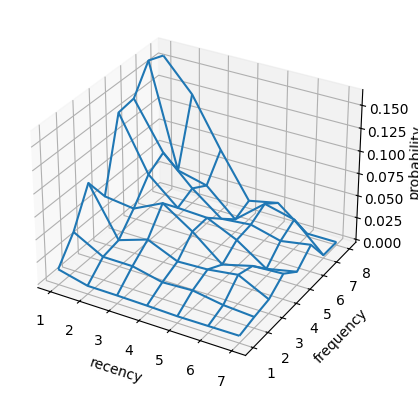

In [5]:
fig_emp = scorer.plot_probability_surface(kind="empirical")

## 4. Optimize — Monotonicity Constraints (mono)

`kind='mono'` enforces that probabilities are monotone decreasing in recency
and monotone increasing in frequency.

=== show solve info ===
kind: mono
status: optimal
objective_value: 0.7913
elapsed_time: 0.04[s]
num_variables: 56
num_constraints: 209


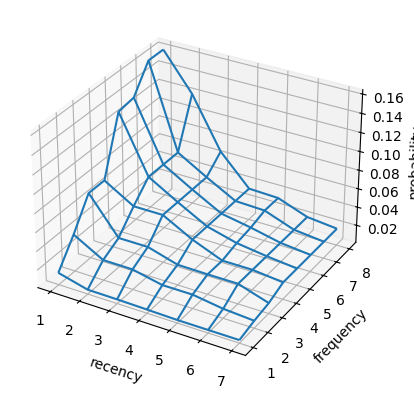

In [6]:
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")

## 5. Optimize — MCC Constraints (mcc)

`kind='mcc'` additionally imposes convexity in recency and concavity in frequency
(diminishing marginal returns), yielding a smoother surface.

=== show solve info ===
kind: mcc
status: optimal
objective_value: 1.8428
elapsed_time: 0.07[s]
num_variables: 56
num_constraints: 291


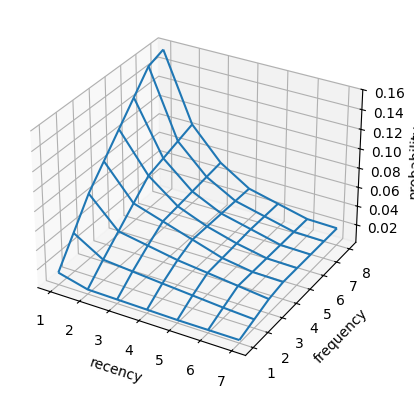

In [7]:
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

## 6. Transform — Generate Recommendation Scores

`transform()` scores each user–item pair in the test log.
Within each user, rows are sorted by `probability` descending;
`order` represents the recommendation rank (1 = top recommendation).

In [8]:
df_rec = scorer.transform(
    df_test,
    target_date,
    kind="mcc",
    user_col="user_id",
    item_col="item_id",
    datetime_col="date",
)
df_rec.head(10)

,user_id,item_id,recency,frequency,probability,order
9190,100099,311656,4,1,0.005009,1
9191,100099,411961,4,1,0.005009,2
9192,100129,353070,5,4,0.024996,1
9196,100138,591186,6,4,0.020067,1
9193,100138,852831,6,3,0.020067,2
9194,100138,1111746,6,2,0.012395,3
9197,100138,81286,2,1,0.006109,4
9198,100138,587992,2,1,0.006109,5
9199,100138,686685,2,1,0.006109,6
9200,100138,328892,2,1,0.006109,7


## 7. Evaluate — Recommendation Quality

Ground-truth revisits are interactions in `df_test` after `target_date`.
`evaluate()` reports precision, recall, and F1 at each recommendation rank cutoff.

In [9]:
df_test_eval = df_test[df_test.date > target_date]
UIrevisit = set(zip(df_test_eval.user_id, df_test_eval.item_id))
print(f"Ground-truth revisits: {len(UIrevisit):,} user–item pairs")

scorer.evaluate(df_rec, UIrevisit, order=5)

Ground-truth revisits: 5,775 user–item pairs


,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,104,0.018749,0.018009,0.018371,0.280323,0.035147
1,2,10583,166,0.015686,0.028745,0.020296,0.447439,0.030309
2,3,14336,209,0.014579,0.036190,0.020785,0.563342,0.028422
3,4,17322,240,0.013855,0.041558,0.020782,0.646900,0.027129
4,5,19742,261,0.013221,0.045195,0.020457,0.703504,0.025953
5,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929
